In [57]:
pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 6.8 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993227 sha256=54f051c0c287df2dd472fc50c989ad6d2909638820da68886d57c511079d1baa
  Stored in directory: /Users/tahiti/Library/Caches/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
Note: you may need to restart the kernel to use updated packages.


In [129]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException

DetectorFactory.seed = 0

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

df = pd.read_excel("Combined_comments.xlsx")

df = df.dropna(subset=['Comment'])

def is_english(text):
    try:
        return detect(str(text)) == 'en' 
    except LangDetectException:
        return False

df = df[df['Comment'].apply(is_english)]

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"[^a-zA-Z\s]", '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df['Cleaned_Comment'] = df['Comment'].apply(clean_text)

df.to_excel("Cleaned_Combined_comments.xlsx", index=False)


[nltk_data] Downloading package punkt to /Users/tahiti/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tahiti/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/tahiti/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [31]:
pip install openpyxl 

Note: you may need to restart the kernel to use updated packages.


In [29]:

!pip install spacy numpy pandas textblob vaderSentiment


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 10.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.3/624.3 kB 10.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.2/133.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 636.7/636.7 kB 7.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 890.2/890.2 kB 8.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 10.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 4.6 MB/s eta 0:00

In [131]:
import pandas as pd
import spacy,re,os,numpy as np
from spacy.lang.en.stop_words import STOP_WORDS
from  string  import  punctuation     
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_excel('Combined_comments.xlsx')
print("Dataset size : " ,df.shape)
df.head(1)

Dataset size :  (13253, 3)


,UserID,Date,Comment
0,Ciprian Bujor,2024-12-03 19:00:30+00:00,"Presați de parlamentarii europeni, reprezentan..."


In [53]:
pip install googletrans==4.0.0-rc1 pandas vaderSentiment textblob

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 8.0 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17395 sha256=ef24084b42592675b07c2c0e7c0513f081a130c108c48031a5dfd9472402b58e
  Stored in directory: /Users/tahiti/Library/Caches/pip/wheels/95/0f/04/b17a72024b56a60e499ce1a6313d283ed5ba332407155bee03
Successfully built googletrans
  Attempting uninstall: h11
    Found existing installation: h11 0.14.0
    Uninstalling

In [135]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

df = pd.read_excel("Cleaned_Combined_comments.xlsx")

df = df.dropna(subset=['Cleaned_Comment'])

all_words = ' '.join(df['Cleaned_Comment']).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(50)
print("Top 50 most common words:")
for word, freq in common_words:
    print(f"{word}: {freq}")

common_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
common_df.to_excel("Top50_common_words.xlsx", index=False)

[nltk_data] Downloading package punkt to /Users/tahiti/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/tahiti/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/tahiti/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Top 50 most common words:
tiktok: 1716
ban: 909
like: 703
u: 687
people: 686
dont: 561
banned: 529
get: 528
one: 444
trump: 438
china: 406
need: 364
time: 360
want: 343
app: 325
know: 316
would: 315
make: 304
im: 299
account: 299
go: 293
even: 288
cant: 287
thing: 285
free: 279
right: 277
tok: 269
platform: 269
thats: 266
video: 266
think: 261
medium: 261
x: 257
good: 255
american: 254
see: 254
chinese: 253
tik: 246
government: 242
say: 238
got: 235
content: 228
speech: 223
well: 210
love: 210
social: 208
much: 207
never: 204
youre: 204
keep: 204


In [137]:
custom_stopwords = {
    'u', 'people', 'get', 'one', 'need', 'know', 'would', 'make', 'im', 'account', 'go', 'even', 'thing',  'tok', 'thats', 'x', 'see', 'tik', 'say', 'got', 'much', 
    'never', 'youre', 'keep'
}

stop_words = set(stopwords.words('english'))
extended_stopwords = stop_words.union(custom_stopwords)

lemmatizer = WordNetLemmatizer()

def clean_text_v2(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"[^a-zA-Z\s]", '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in extended_stopwords]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df['Cleaned_Comment_v1'] = df['Comment'].apply(clean_text_v2)

df.to_excel("Cleaned_Comments_v1.xlsx", index=False)
print("The second round of cleaning has been completed and the file has been saved as 'Cleaned_Comments_v1.xlsx'")


The second round of cleaning has been completed and the file has been saved as 'Cleaned_Comments_v1.xlsx'


In [139]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

df = pd.read_excel("Cleaned_Comments_v1.xlsx")

def sentiment_vader_scores(text):
    analyser = SentimentIntensityAnalyzer()
    return analyser.polarity_scores(text)['compound']  

def sentiment_textblob_scores(text):
    return TextBlob(text).sentiment.polarity

df['Cleaned_Comment_v1'] = df['Cleaned_Comment_v1'].fillna("").astype(str)
df['vader_score'] = df['Cleaned_Comment_v1'].apply(sentiment_vader_scores)
df['textblob_score'] = df['Cleaned_Comment_v1'].apply(sentiment_textblob_scores)

print("\nThe first five results:")
print(df[['Cleaned_Comment_v1', 'vader_score', 'textblob_score']].head())

output_filename = "Sentiment_Analysis_Results.xlsx"
df.to_excel(output_filename, index=False)
print(f"\nThe result has been saved to {output_filename}")


The first five results:
                                  Cleaned_Comment_v1  vader_score  \
0  illr u tiktok ban horizon triller positioned t...      -0.5574   
1                             canada ban tiktok late      -0.5574   
2  tiktok suck russia problem everything russia f...      -0.7717   
3  lack interest knowing truth problem course eve...       0.4767   
4  ban bad financial advice alone let alone anyth...      -0.8779   

   textblob_score  
0        0.214286  
1       -0.300000  
2       -0.100000  
3        0.225000  
4       -0.350000  

The result has been saved to Sentiment_Analysis_Results.xlsx


In [141]:
import numpy as np
import pandas as pd

df['sentiment_scores'] = np.mean(np.array([df['textblob_score'], df['vader_score']]), axis=0)

df['Sentiment'] = df['sentiment_scores'].apply(lambda x: 'neg' if x < 0 else 'pos' if x > 0 else 'neutral')
df['Textblob_sentiment'] = df['textblob_score'].apply(lambda x: 'neg' if x < 0 else 'pos' if x > 0 else 'neutral')
df['Vader_sentiment'] = df['vader_score'].apply(lambda x: 'neg' if x < 0 else 'pos' if x > 0 else 'neutral')

print("The distribution of Sentiment labels after fusion：")
print(df['Sentiment'].value_counts())

print("\nTextBlob tag distribution：")
print(df['Textblob_sentiment'].value_counts())

print("\nVADER tag distribution：")
print(df['Vader_sentiment'].value_counts())


The distribution of Sentiment labels after fusion：
Sentiment
pos        3923
neg        3768
neutral    1762
Name: count, dtype: int64

TextBlob tag distribution：
Textblob_sentiment
neutral    3934
pos        3296
neg        2223
Name: count, dtype: int64

VADER tag distribution：
Vader_sentiment
neg        3674
pos        3418
neutral    2361
Name: count, dtype: int64


In [143]:
columns_to_save = [
    'UserID',
    'Date',
    'Comment',
    'Cleaned_Comment_v1',
    'textblob_score', 'Textblob_sentiment',
    'vader_score', 'Vader_sentiment',
    'sentiment_scores', 'Sentiment'
]

output_file = 'Sentiment_Labelled_Comments.xlsx'

df.to_excel(output_file, columns=columns_to_save, index=False)
print(f"The data after emotion annotation has been saved to：{output_file}")


The data after emotion annotation has been saved to：Sentiment_Labelled_Comments.xlsx


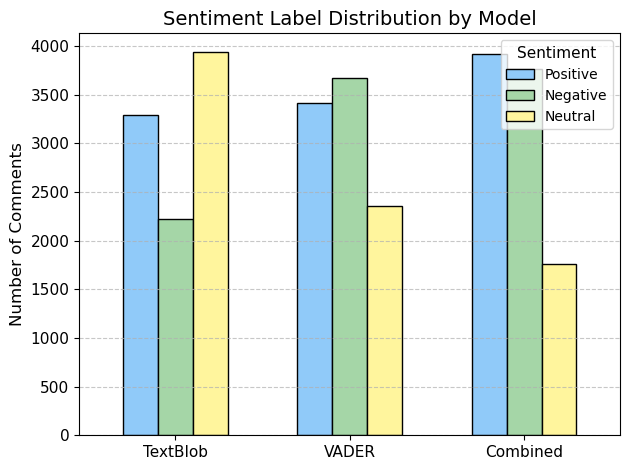

In [145]:
import matplotlib.pyplot as plt
import pandas as pd

pos = [3296, 3418, 3923]
neg = [2223, 3674, 3768]
neutral = [3934, 2361, 1762]
index = ['TextBlob', 'VADER', 'Combined']

ddf = pd.DataFrame({
    'Positive': pos,
    'Negative': neg,
    'Neutral': neutral
}, index=index)

colors = ['#90CAF9', '#A5D6A7', '#FFF59D']  

ax = ddf.plot(kind='bar', color=colors, rot=0, width=0.6, edgecolor='black')

plt.title('Sentiment Label Distribution by Model', fontsize=14)
plt.ylabel('Number of Comments', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Sentiment', title_fontsize=11, fontsize=10)
plt.tight_layout()

plt.savefig('sentiment_label_distribution.png', dpi=300)
plt.show()